# Ethernet U3-S2

O que é Ethernet? (A Base)
Imagine que a Ethernet é o "sistema de encanamento" ou as "estradas" da internet local. Ela define as regras físicas (cabos) e as regras de etiqueta (protocolos) para que os dados saiam do ponto A e cheguem ao ponto B sem se perderem no caminho.

O CSMA/CD (que simularemos abaixo) é a regra de etiqueta para evitar que as mensagens batam umas nas outras.

TABELA 1: RESULTADOS DA SIMULAÇÃO DE CONTENÇÃO ETHERNET
 Num_Hosts  Prob_Sucesso  Eficiencia_Percentual  Vazao_Estimada_Mbps
         2        0.5000                  95.24                95.24
         4        0.4219                  93.59                93.59
         6        0.4019                  93.07                93.07
         8        0.3927                  92.82                92.82
        10        0.3874                  92.67                92.67
        12        0.3840                  92.57                92.57
        14        0.3816                  92.50                92.50
        16        0.3798                  92.45                92.45
        18        0.3784                  92.41                92.41
        20        0.3774                  92.38                92.38
        22        0.3765                  92.35                92.35
        24        0.3757                  92.33                92.33
        26        0.3751                  92.31

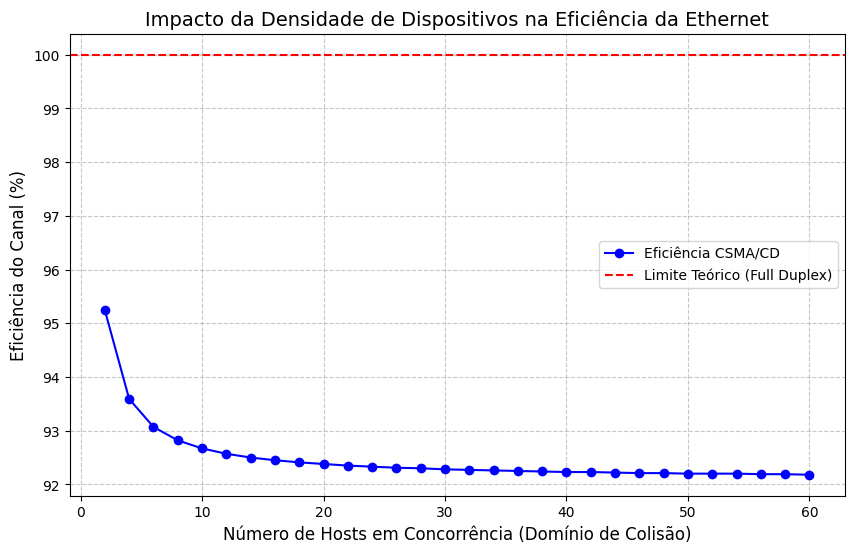


[INFO] O arquivo 'grafico.png' foi gerado e está pronto para o Zenodo/Artigo.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simular_eficiencia_ethernet(max_hosts, frames_por_host=1000):
    """
    Simula a eficiência do protocolo CSMA/CD conforme o aumento de dispositivos.
    """
    resultados = []

    # Parâmetros: 'a' representa a razão entre atraso de propagação e tempo de transmissão
    # Para Ethernet padrão 100Mbps em 100m, 'a' é aproximadamente 0.01
    a = 0.01

    for n in range(2, max_hosts + 1, 2):
        # Probabilidade ótima de transmissão p = 1/n para maximizar sucesso
        p = 1 / n

        # Probabilidade de exatamente um host transmitir com sucesso em um slot
        prob_sucesso = n * p * ((1 - p) ** (n - 1))

        # Eficiência teórica baseada no modelo de Tanenbaum/Metcalfe
        # Eficiência = 1 / (1 + 2a(1-A)/A) onde A é a prob de sucesso
        eficiencia = 1 / (1 + (5 * a * (1 - prob_sucesso) / prob_sucesso))

        resultados.append({
            'Num_Hosts': n,
            'Prob_Sucesso': round(prob_sucesso, 4),
            'Eficiencia_Percentual': round(eficiencia * 100, 2),
            'Vazao_Estimada_Mbps': round(100 * eficiencia, 2)
        })

    return pd.DataFrame(resultados)

# 1. Executar Simulação
df_final = simular_eficiencia_ethernet(max_hosts=60)

# 2. Exibir Tabela de Dados Formatada
print("TABELA 1: RESULTADOS DA SIMULAÇÃO DE CONTENÇÃO ETHERNET")
print("="*60)
print(df_final.to_string(index=False))
print("="*60)

# 3. Gerar e Salvar Gráfico Científico
plt.figure(figsize=(10, 6))
plt.plot(df_final['Num_Hosts'], df_final['Eficiencia_Percentual'],
         marker='o', linestyle='-', color='b', label='Eficiência CSMA/CD')

plt.title('Impacto da Densidade de Dispositivos na Eficiência da Ethernet', fontsize=14)
plt.xlabel('Número de Hosts em Concorrência (Domínio de Colisão)', fontsize=12)
plt.ylabel('Eficiência do Canal (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=100, color='r', linestyle='--', label='Limite Teórico (Full Duplex)')
plt.legend()

# Salvar para o artigo
plt.savefig('grafico.png', dpi=300)
plt.show()

print("\n[INFO] O arquivo 'grafico.png' foi gerado e está pronto para o Zenodo/Artigo.")